# ==========================================
# 1. Import Libraries
# ==========================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # Import Pipeline from sklearn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


# Models

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ==========================================
# 2. Data Loading & Preprocessing
# ==========================================

In [4]:
import pandas as pd


df = pd.read_csv(f"/Users/qubit/Desktop/Level2/dataset3.csv")

print("First 5 records:")
df.head()

First 5 records:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


In [8]:
len(df)

145460

In [9]:
df.size

3345580

In [10]:
df.shape

(145460, 23)

In [11]:
df.isnull().mean().sort_values(ascending=False)

Sunshine         0.480098
Evaporation      0.431665
Cloud3pm         0.408071
Cloud9am         0.384216
Pressure9am      0.103568
Pressure3pm      0.103314
WindDir9am       0.072639
WindGustDir      0.070989
WindGustSpeed    0.070555
Humidity3pm      0.030984
WindDir3pm       0.029066
Temp3pm          0.024811
RainTomorrow     0.022460
Rainfall         0.022419
RainToday        0.022419
WindSpeed3pm     0.021050
Humidity9am      0.018246
Temp9am          0.012148
WindSpeed9am     0.012148
MinTemp          0.010209
MaxTemp          0.008669
Location         0.000000
Date             0.000000
dtype: float64

<Axes: >

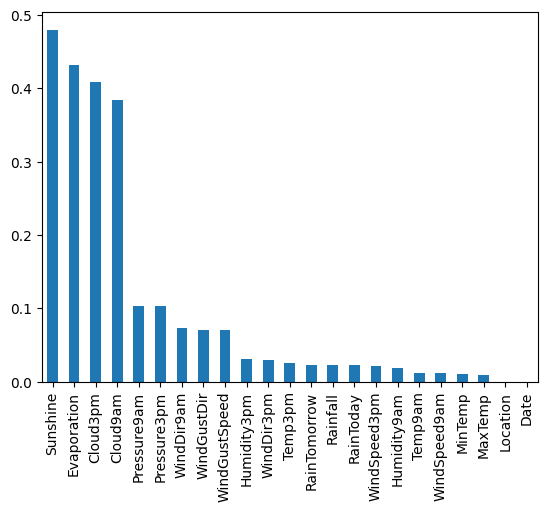

In [12]:
df.isnull().mean().sort_values(ascending=False).plot(kind='bar')

In [13]:
df['RainTomorrow'].value_counts(dropna=False)

RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

# Drop rows where target variable is missing (critical for supervised learning)

In [14]:
df.dropna(subset=['RainTomorrow'], inplace=True)


# Encode Target Variable

In [15]:
df['RainTomorrow']= df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# ==========================================
# 3. Advanced Feature Engineering
# ==========================================

In [16]:
print("Engineering features...")

Engineering features...


# Parse Date and extract cyclical temporal features

In [17]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# Cyclical encoding for Month using Sin/Cos

In [18]:
import numpy as np
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Advanced Meteorological Features (Differences)

In [19]:
df['TempDiff'] = df['MaxTemp'] - df['MinTemp']
df['PressureDiff'] = df['Pressure9am'] - df['Pressure3pm']
df['HumidityDiff'] = df['Humidity9am'] - df['Humidity3pm']

# Drop original Date column as it's no longer needed

In [20]:
df.drop(['Date', 'Month'], axis=1, inplace=True)

# Separate Features (X) and Target (y)

In [21]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# Identify numerical and categorical columns

In [22]:
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# ==========================================
# 4. Outlier Handling (IQR Clipping)
# ==========================================

In [23]:
print("Handling outliers using IQR clipping...")
def clip_outliers(df_in, columns):
    df_out = df_in.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_out[col] = np.clip(df_out[col], lower_bound, upper_bound)
    return df_out

X = clip_outliers(X, num_cols)

Handling outliers using IQR clipping...


# Train-Test Split (Hold-out set for final evaluation)

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ==========================================
# 5. Data Cleaning & Dimensionality Reduction Pipelines
# ==========================================

In [25]:
print("Building scikit-learn pipelines...")

Building scikit-learn pipelines...


# Numerical Preprocessing: Median Imputation -> Scaling

In [26]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Preprocessing: Mode Imputation -> One-Hot Encoding

In [27]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine Preprocessors

In [28]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# ==========================================
# 6. Model Definition & Cross-Validation Setup
# ==========================================

In [29]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
}

# Stratified K-Fold for robust evaluation

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 7. Model Fitting & Evaluation
# ==========================================

In [31]:
results = []

print("Training models... This might take a moment depending on your hardware.")
for model_name, model in models.items():
    
    # Complete Imblearn Pipeline (Avoids Data Leakage)
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), # Handles class imbalance
        ('pca', PCA(n_components=0.95, random_state=42)), # Retains 95% variance
        ('classifier', model)
    ])
    
    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"✔️ {model_name} trained and evaluated.")

Training models... This might take a moment depending on your hardware.
✔️ Logistic Regression trained and evaluated.
✔️ Random Forest trained and evaluated.
✔️ XGBoost trained and evaluated.
✔️ LightGBM trained and evaluated.


In [32]:
%pip install tab-transformer-pytorch

Note: you may need to restart the kernel to use updated packages.


# ==========================================
# 8. Leaderboard & Visualization
# ==========================================

# Create a DataFrame for results and sort by ROC-AUC

In [33]:
leaderboard = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("🏆 FINAL MODEL LEADERBOARD 🏆")
print("="*50)
print(leaderboard.to_string(index=False))


🏆 FINAL MODEL LEADERBOARD 🏆
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
           LightGBM  0.813285   0.562802 0.748549  0.642521 0.876681
      Random Forest  0.838532   0.635507 0.655843  0.645515 0.875193
Logistic Regression  0.792433   0.525074 0.775216  0.626085 0.869285
            XGBoost  0.816801   0.573427 0.713569  0.635868 0.869126


# Plotting the Leaderboard Comparison

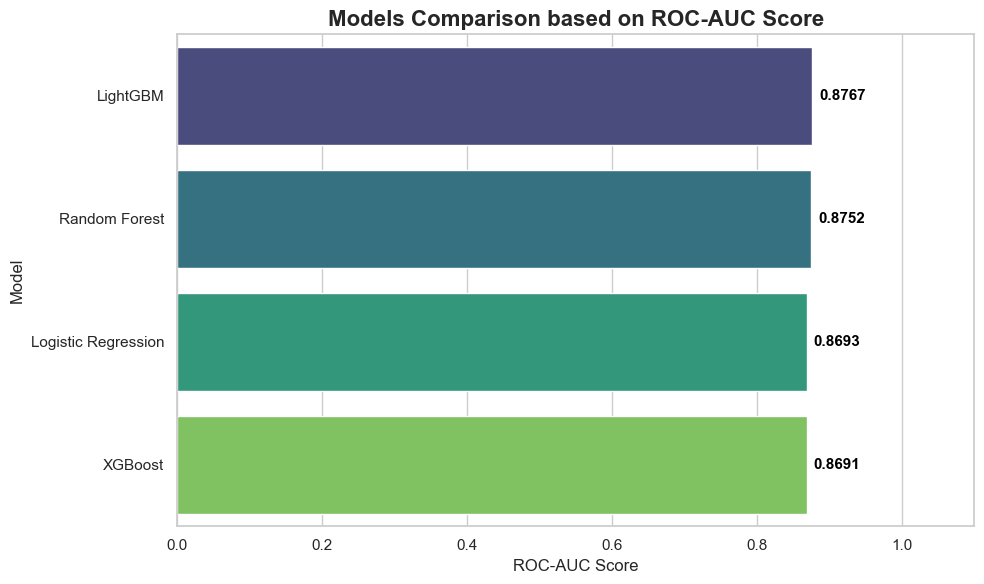

In [34]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='ROC-AUC', y='Model', data=leaderboard, palette='viridis')

# Add values on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points', 
                fontsize=11, color='black', weight='bold')

plt.title('Models Comparison based on ROC-AUC Score', fontsize=16, weight='bold')
plt.xlabel('ROC-AUC Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1.1)
plt.tight_layout()

# Save the plot (great for GitHub README or Kaggle Notebook)
plt.savefig('models_comparison_leaderboard.png', dpi=300)
plt.show()

In [35]:
import requests
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


LATITUDE = 24.4850
LONGITUDE = 86.6947

TARGET = "RainTomorrow"

FEATURES = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Evaporation",
    "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Cloud9am",
    "Cloud3pm",
    "Temp9am",
    "Temp3pm",
    "Month_Sin",
    "Month_Cos",
    "TempDiff",
    "PressureDiff",
    "HumidityDiff"
]


print("=" * 70)
print("DEOGHAR RAIN TOMORROW - ENSEMBLE MODEL")
print("=" * 70)


X = df[FEATURES].copy()
y = df[TARGET].copy()


if y.dtype == "object":
    y = (
        y.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "yes": 1,
            "no": 0
        })
    )


valid = y.notna()

X = X.loc[valid].copy()
y = y.loc[valid].astype(int)


print("\nTraining samples:", len(X))


rf_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


xgb_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


lgbm_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                num_leaves=31,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)


lr_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


print("\nTraining Random Forest...")
rf_model.fit(X, y)

print("Training XGBoost...")
xgb_model.fit(X, y)

print("Training LightGBM...")
lgbm_model.fit(X, y)

print("Training Logistic Regression...")
lr_model.fit(X, y)

print("\nAll models trained successfully.")


today = (
    pd.Timestamp.now(
        tz="Asia/Kolkata"
    )
    .normalize()
    .tz_localize(None)
)

tomorrow = today + pd.Timedelta(days=1)


print("\n")
print("=" * 70)
print("GETTING REAL-WORLD WEATHER")
print("=" * 70)

print("Today    :", today.date())
print("Tomorrow :", tomorrow.date())


url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "past_days": 2,
    "forecast_days": 2,
    "hourly": (
        "temperature_2m,"
        "relative_humidity_2m,"
        "dew_point_2m,"
        "surface_pressure,"
        "wind_speed_10m,"
        "wind_direction_10m,"
        "cloud_cover,"
        "soil_moisture_0_to_7cm,"
        "soil_moisture_7_to_28cm"
    ),
    "timezone": "Asia/Kolkata"
}


response = requests.get(
    url,
    params=params,
    timeout=30
)

response.raise_for_status()

data = response.json()


weather = pd.DataFrame(
    data["hourly"]
)

weather["ds"] = pd.to_datetime(
    weather["time"]
)


weather = weather.rename(
    columns={
        "temperature_2m": "T2M",
        "relative_humidity_2m": "RH2M",
        "dew_point_2m": "T2MDEW",
        "surface_pressure": "PS",
        "wind_speed_10m": "WS10M",
        "wind_direction_10m": "WD10M",
        "cloud_cover": "CLOUD_AMT",
        "soil_moisture_0_to_7cm": "GWETTOP",
        "soil_moisture_7_to_28cm": "GWETROOT"
    }
)


daily_weather = (
    weather
    .set_index("ds")
    .resample("D")
    .agg({
        "T2M": "mean",
        "T2MDEW": "mean",
        "RH2M": "mean",
        "PS": "mean",
        "WS10M": "mean",
        "WD10M": "mean",
        "CLOUD_AMT": "mean",
        "GWETTOP": "mean",
        "GWETROOT": "mean"
    })
    .reset_index()
)


daily_weather["TempDiff"] = (
    daily_weather["T2M"]
    -
    daily_weather["T2MDEW"]
)


daily_weather["PressureDiff"] = (
    daily_weather["PS"]
    .diff()
    .abs()
)


daily_weather["HumidityDiff"] = (
    daily_weather["RH2M"]
    .diff()
    .abs()
)


daily_weather["Month"] = (
    daily_weather["ds"].dt.month
)


daily_weather["Month_Sin"] = np.sin(
    2 * np.pi *
    daily_weather["Month"] / 12
)


daily_weather["Month_Cos"] = np.cos(
    2 * np.pi *
    daily_weather["Month"] / 12
)


tomorrow_weather = daily_weather[
    daily_weather["ds"] == tomorrow
].copy()


if len(tomorrow_weather) == 0:
    raise ValueError(
        "Tomorrow's weather data was not returned."
    )


row = tomorrow_weather.iloc[0]


input_data = pd.DataFrame({

    "MinTemp": [
        row["T2M"] - 2
    ],

    "MaxTemp": [
        row["T2M"] + 2
    ],

    "Rainfall": [
        0
    ],

    "Evaporation": [
        np.nan
    ],

    "Sunshine": [
        np.nan
    ],

    "WindGustSpeed": [
        row["WS10M"]
    ],

    "WindSpeed9am": [
        row["WS10M"]
    ],

    "WindSpeed3pm": [
        row["WS10M"]
    ],

    "Humidity9am": [
        row["RH2M"]
    ],

    "Humidity3pm": [
        row["RH2M"]
    ],

    "Pressure9am": [
        row["PS"]
    ],

    "Pressure3pm": [
        row["PS"]
    ],

    "Cloud9am": [
        row["CLOUD_AMT"] / 100
    ],

    "Cloud3pm": [
        row["CLOUD_AMT"] / 100
    ],

    "Temp9am": [
        row["T2M"]
    ],

    "Temp3pm": [
        row["T2M"]
    ],

    "Month_Sin": [
        row["Month_Sin"]
    ],

    "Month_Cos": [
        row["Month_Cos"]
    ],

    "TempDiff": [
        row["TempDiff"]
    ],

    "PressureDiff": [
        row["PressureDiff"]
    ],

    "HumidityDiff": [
        row["HumidityDiff"]
    ]
})


input_data = input_data[
    FEATURES
]


print("\n")
print("=" * 70)
print("REAL-WORLD INPUT")
print("=" * 70)

print(
    input_data.to_string(
        index=False
    )
)


rf_probability = rf_model.predict_proba(
    input_data
)[0]

xgb_probability = xgb_model.predict_proba(
    input_data
)[0]

lgbm_probability = lgbm_model.predict_proba(
    input_data
)[0]

lr_probability = lr_model.predict_proba(
    input_data
)[0]


rf_classes = rf_model.classes_
xgb_classes = xgb_model.classes_
lgbm_classes = lgbm_model.classes_
lr_classes = lr_model.classes_


rf_rain = rf_probability[
    list(rf_classes).index(1)
]

xgb_rain = xgb_probability[
    list(xgb_classes).index(1)
]

lgbm_rain = lgbm_probability[
    list(lgbm_classes).index(1)
]

lr_rain = lr_probability[
    list(lr_classes).index(1)
]


rf_no_rain = rf_probability[
    list(rf_classes).index(0)
]

xgb_no_rain = xgb_probability[
    list(xgb_classes).index(0)
]

lgbm_no_rain = lgbm_probability[
    list(lgbm_classes).index(0)
]

lr_no_rain = lr_probability[
    list(lr_classes).index(0)
]


ensemble_rain_probability = np.mean([
    rf_rain,
    xgb_rain,
    lgbm_rain,
    lr_rain
])


ensemble_no_rain_probability = np.mean([
    rf_no_rain,
    xgb_no_rain,
    lgbm_no_rain,
    lr_no_rain
])


if ensemble_rain_probability >= 0.50:

    prediction = 1

    status = "🌧️ RAIN TOMORROW"

else:

    prediction = 0

    status = "☀️ NO RAIN TOMORROW"


confidence = max(
    ensemble_rain_probability,
    ensemble_no_rain_probability
)


if ensemble_rain_probability < 0.30:

    risk = "LOW"

elif ensemble_rain_probability < 0.60:

    risk = "MODERATE"

elif ensemble_rain_probability < 0.80:

    risk = "HIGH"

else:

    risk = "VERY HIGH"


print("\n")
print("=" * 70)
print("INDIVIDUAL MODEL PREDICTIONS")
print("=" * 70)

print(
    f"Random Forest        : "
    f"{rf_rain * 100:.2f}% rain"
)

print(
    f"XGBoost              : "
    f"{xgb_rain * 100:.2f}% rain"
)

print(
    f"LightGBM             : "
    f"{lgbm_rain * 100:.2f}% rain"
)

print(
    f"Logistic Regression  : "
    f"{lr_rain * 100:.2f}% rain"
)


print("\n")
print("=" * 70)
print("ENSEMBLE RESULT")
print("=" * 70)

print(
    f"🌧️ Rain probability      : "
    f"{ensemble_rain_probability * 100:.2f}%"
)

print(
    f"☀️ No-rain probability   : "
    f"{ensemble_no_rain_probability * 100:.2f}%"
)

print(
    f"Model confidence        : "
    f"{confidence * 100:.2f}%"
)

print(
    f"Prediction              : "
    f"{status}"
)

print(
    f"Rain risk               : "
    f"{risk}"
)

print("=" * 70)

DEOGHAR RAIN TOMORROW - ENSEMBLE MODEL

Training samples: 142193

Training Random Forest...
Training XGBoost...
Training LightGBM...
Training Logistic Regression...

All models trained successfully.


GETTING REAL-WORLD WEATHER
Today    : 2026-08-28
Tomorrow : 2026-08-29


REAL-WORLD INPUT
  MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  Cloud3pm   Temp9am   Temp3pm  Month_Sin  Month_Cos  TempDiff  PressureDiff  HumidityDiff
25.320833 29.320833         0          NaN       NaN       4.708333      4.708333      4.708333    90.541667    90.541667   972.983333   972.983333  0.942917  0.942917 27.320833 27.320833  -0.866025       -0.5     1.725      0.666667      0.666667


INDIVIDUAL MODEL PREDICTIONS
Random Forest        : 35.67% rain
XGBoost              : 51.35% rain
LightGBM             : 86.34% rain
Logistic Regression  : 94.02% rain


ENSEMBLE RESULT
🌧️ Rain probability     

In [43]:
import joblib

model_package = {
    "rf_model": rf_model,
    "xgb_model": xgb_model,
    "lgbm_model": lgbm_model,
    "lr_model": lr_model,
    "preprocessor": preprocessor,
    "features": FEATURES,
    "target": TARGET
}

joblib.dump(
    model_package,
    "rainfall_ensemble.pkl"
)

print("✅ Ensemble saved successfully")
print("File: rainfall_ensemble.pkl")
print("Size:", os.path.getsize("rainfall_ensemble.pkl") / (1024 * 1024), "MB")

✅ Ensemble saved successfully
File: rainfall_ensemble.pkl
Size: 745.5264434814453 MB


In [47]:
import os

print(os.path.exists("rainfall_ensemble.pkl"))
print(os.path.abspath("rainfall_ensemble.pkl"))

True
/Users/qubit/Desktop/Level2/rainfall_ensemble.pkl


In [48]:
import joblib

loaded_model = joblib.load(
    "/Users/qubit/Desktop/Level2/rainfall_ensemble.pkl"
)

print("Model loaded successfully!")
print(loaded_model.keys())

Model loaded successfully!
dict_keys(['rf_model', 'xgb_model', 'lgbm_model', 'lr_model', 'preprocessor', 'features', 'target'])


In [50]:
import joblib

package = joblib.load(
    "/Users/qubit/Desktop/Level2/rainfall_ensemble.pkl"
)

print("FEATURES:")
print(package["features"])

print("\nTARGET:")
print(package["target"])

print("\nPREPROCESSOR:")
print(package["preprocessor"])

print("\nPREPROCESSOR FEATURE COUNT:")
print(
    len(
        package["preprocessor"].feature_names_in_
    )
)

print("\nPREPROCESSOR INPUT FEATURES:")
print(
    package["preprocessor"].feature_names_in_
)

print("\nMODEL INPUT SIZES:")

print(
    "Random Forest:",
    package["rf_model"].n_features_in_
)

print(
    "XGBoost:",
    package["xgb_model"].n_features_in_
)

print(
    "LightGBM:",
    package["lgbm_model"].n_features_in_
)

print(
    "Logistic Regression:",
    package["lr_model"].n_features_in_
)

FEATURES:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Month_Sin', 'Month_Cos', 'TempDiff', 'PressureDiff', 'HumidityDiff']

TARGET:
RainTomorrow

PREPROCESSOR:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'Month_Sin', 'Month_Cos', 'TempDiff',
       'PressureDiff', 'HumidityDiff'],
      dtype='object')),
                    

In [51]:
import joblib

package = joblib.load(
    "/Users/qubit/Desktop/Level2/rainfall_ensemble.pkl"
)

for name in [
    "rf_model",
    "xgb_model",
    "lgbm_model",
    "lr_model"
]:

    model = package[name]

    print("\n", name)

    print("Expected features:",
          model.n_features_in_)

    print("Model type:",
          type(model))

    if hasattr(model, "feature_names_in_"):
        print(
            "Feature names:",
            model.feature_names_in_
        )


 rf_model
Expected features: 21
Model type: <class 'sklearn.pipeline.Pipeline'>
Feature names: ['MinTemp' 'MaxTemp' 'Rainfall' 'Evaporation' 'Sunshine' 'WindGustSpeed'
 'WindSpeed9am' 'WindSpeed3pm' 'Humidity9am' 'Humidity3pm' 'Pressure9am'
 'Pressure3pm' 'Cloud9am' 'Cloud3pm' 'Temp9am' 'Temp3pm' 'Month_Sin'
 'Month_Cos' 'TempDiff' 'PressureDiff' 'HumidityDiff']

 xgb_model
Expected features: 21
Model type: <class 'sklearn.pipeline.Pipeline'>
Feature names: ['MinTemp' 'MaxTemp' 'Rainfall' 'Evaporation' 'Sunshine' 'WindGustSpeed'
 'WindSpeed9am' 'WindSpeed3pm' 'Humidity9am' 'Humidity3pm' 'Pressure9am'
 'Pressure3pm' 'Cloud9am' 'Cloud3pm' 'Temp9am' 'Temp3pm' 'Month_Sin'
 'Month_Cos' 'TempDiff' 'PressureDiff' 'HumidityDiff']

 lgbm_model
Expected features: 21
Model type: <class 'sklearn.pipeline.Pipeline'>
Feature names: ['MinTemp' 'MaxTemp' 'Rainfall' 'Evaporation' 'Sunshine' 'WindGustSpeed'
 'WindSpeed9am' 'WindSpeed3pm' 'Humidity9am' 'Humidity3pm' 'Pressure9am'
 'Pressure3pm' 'Cloud9a